# Global Dataset Exploratory Data Analysis (EDA)

## Objective
- Memahami pola data global
- Mengidentifikasi tren skill dan role
- Membandingkan dengan dataset local

---

## 1. Load Dataset
- Import library (`pandas`, `matplotlib`, `seaborn`)
- Load `global_jobs_cleaned.csv`
- Cek shape dan preview data

---

## 2. Overview Dataset
- Total jumlah data
- Jumlah kolom
- Distribusi data (basic info)

---

## 3. Distribusi Role
- Hitung jumlah tiap `role`
- Visualisasi (bar chart)
- Identifikasi role paling dominan

---

## 4. Distribusi Skill
- Ekstrak semua skill dari `skills_cleaned`
- Hitung frekuensi skill
- Tampilkan:
  - Top 10 / Top 20 skill
- Visualisasi

---

## 5. Skills Count Analysis
- Rata-rata jumlah skill (`skills_count`)
- Distribusi skill count
- Insight:
  - apakah job global lebih kompleks?

---

## 6. Location Analysis (jika ada)
- Distribusi kota / negara
- Identifikasi lokasi dominan

---

## 7. Insight Summary (Global)
Tuliskan poin-poin penting:
- Skill paling banyak dicari
- Role dominan
- Kompleksitas job

---

## 8. Comparison: Global vs Local

Bandingkan dengan dataset local:

### Role
- Role dominan global vs local

### Skills
- Skill populer global vs local

### Complexity
- Rata-rata skill count

---

## 9. Key Insights
Tuliskan 3–5 insight utama, contoh:

- Perbedaan kebutuhan skill global vs Indonesia
- Kecenderungan skill lebih advanced atau basic
- Perbedaan distribusi role

---

## 10. Conclusion
- Ringkasan singkat hasil analisis
- Relevansi terhadap project (recommendation system)

# **Sel 1: Load Dataset**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Atur tema visualisasi
sns.set_theme(style="whitegrid")

# Load global dataset hasil pembersihan
df_global = pd.read_csv('global_data_intern_cleaned.csv')

# Cek shape dan preview
print(f"Shape dataset: {df_global.shape}")
display(df_global.head())

Shape dataset: (125, 5)


,Internship_Domain,role,raw_skills,skills_cleaned,skills_count
0,Data Science,data scientist,"MongoDB, SQL, Docker, HTML, Pandas","docker, html, mongodb, pandas, sql",5
1,AI/ML,ai/ml,"Kubernetes, Python, C++, MongoDB","cpp, kubernetes, mongodb, python",4
2,Data Science,data scientist,"SQL, Node.js, CSS, Docker, C++","cpp, css, docker, node, sql",5
3,Data Science,data scientist,"React, HTML, Pandas, CSS, Python","css, html, pandas, python, react",5
4,AI/ML,ai/ml,"HTML, Kubernetes, JavaScript, C++","cpp, html, javascript, kubernetes",4


# **Sel 2: Overview Dataset**

In [3]:
print("=== Overview Dataset ===")
print(f"Total baris (jumlah data): {df_global.shape[0]}")
print(f"Total kolom: {df_global.shape[1]}")

print("\n=== Distribusi Data (Basic Info) ===")
df_global.info()

print("\n=== Statistik Numerik ===")
display(df_global.describe())

=== Overview Dataset ===
Total baris (jumlah data): 125
Total kolom: 5

=== Distribusi Data (Basic Info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Internship_Domain  125 non-null    object
 1   role               125 non-null    object
 2   raw_skills         125 non-null    object
 3   skills_cleaned     125 non-null    object
 4   skills_count       125 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 5.0+ KB

=== Statistik Numerik ===


,skills_count
count,125.000000
mean,4.472000
std,1.161034
min,3.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,6.000000


# **Sel 3: Distribusi Role**

,count
role,
ai/ml,64
data scientist,61


/tmp/ipykernel_7611/2138943675.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_counts.index, y=role_counts.values, palette='viridis')


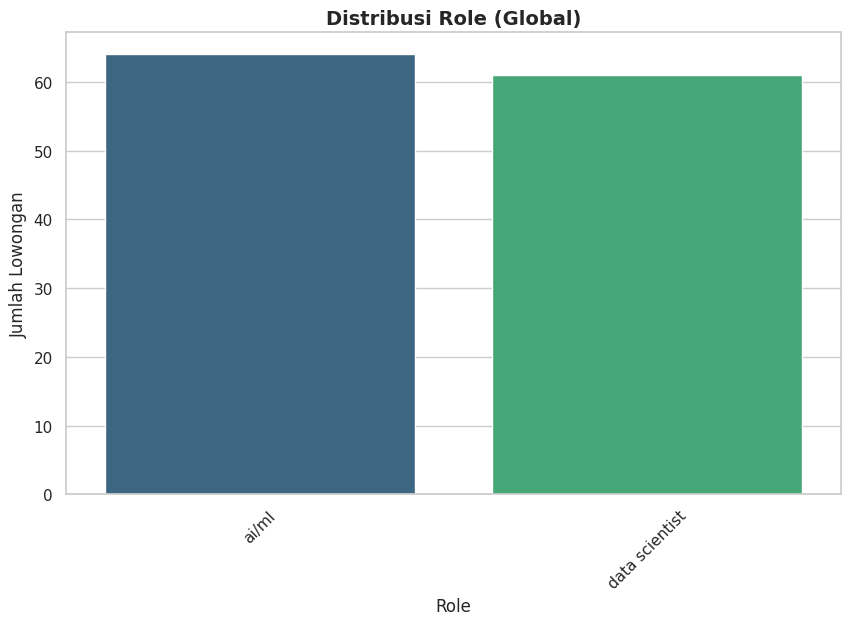

📌 Role paling dominan adalah 'ai/ml' dengan total 64 lowongan.


In [4]:
# Hitung frekuensi tiap role
role_counts = df_global['role'].value_counts()
display(role_counts)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x=role_counts.index, y=role_counts.values, palette='viridis')
plt.title('Distribusi Role (Global)', fontsize=14, fontweight='bold')
plt.xlabel('Role', fontsize=12)
plt.ylabel('Jumlah Lowongan', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Identifikasi dominan
print(f"📌 Role paling dominan adalah '{role_counts.index[0]}' dengan total {role_counts.values[0]} lowongan.")

# **Sel 4: Distribusi Skill (Top 10)**

=== Top 15 Skill Paling Banyak Dicari ===


,Skill,Frequency
0,python,47
1,kubernetes,47
2,react,47
3,css,47
4,html,43
5,tensorflow,43
6,cpp,41
7,mongodb,40
8,pandas,39
9,node,36


/tmp/ipykernel_7611/3161199308.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_skills_global.head(15), x='Frequency', y='Skill', palette='magma')


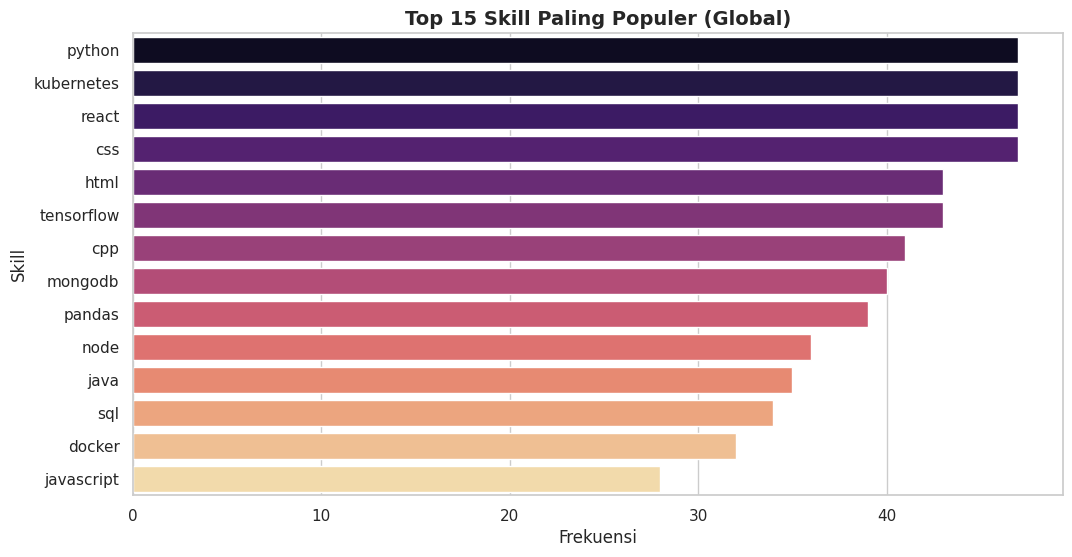

In [5]:
from collections import Counter

# Ekstrak semua skill
all_skills_global = []
for skills in df_global['skills_cleaned'].dropna():
    skill_list = str(skills).split(', ')
    all_skills_global.extend(skill_list)

# Hitung frekuensi
skill_counts_global = Counter(all_skills_global)
df_skills_global = pd.DataFrame(skill_counts_global.items(), columns=['Skill', 'Frequency'])
df_skills_global = df_skills_global.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

print("=== Top 15 Skill Paling Banyak Dicari ===")
display(df_skills_global.head(15))

# Visualisasi Top 15
plt.figure(figsize=(12, 6))
sns.barplot(data=df_skills_global.head(15), x='Frequency', y='Skill', palette='magma')
plt.title('Top 15 Skill Paling Populer (Global)', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.show()

# **Sel 5: Skills Count Analysis**

Rata-rata skill per lowongan (Global): 4.47 skills


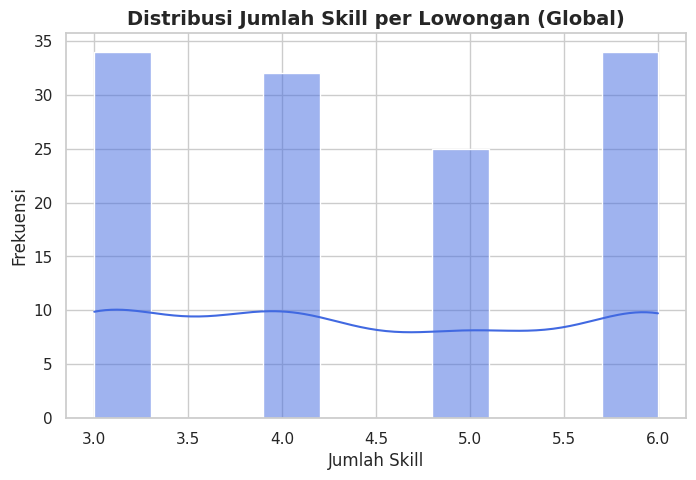

In [6]:
# Hitung rata-rata
avg_skill_global = df_global['skills_count'].mean()
print(f"Rata-rata skill per lowongan (Global): {avg_skill_global:.2f} skills")

# Visualisasi Distribusi
plt.figure(figsize=(8, 5))
sns.histplot(df_global['skills_count'], bins=10, kde=True, color='royalblue')
plt.title('Distribusi Jumlah Skill per Lowongan (Global)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Skill', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

# **Sel 6: Location Analysis (Code)**

In [7]:
# Mengecek apakah ada kolom lokasi
if 'location_city' in df_global.columns:
    loc_counts = df_global['location_city'].value_counts().head(10)
    display(loc_counts)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=loc_counts.values, y=loc_counts.index, palette='crest')
    plt.title('Top 10 Lokasi Dominan (Global)', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Lowongan', fontsize=12)
    plt.ylabel('Lokasi', fontsize=12)
    plt.show()
else:
    print("📌 Info: Kolom 'location_city' atau data lokasi spesifik tidak tersedia di dataset global ini.")

📌 Info: Kolom 'location_city' atau data lokasi spesifik tidak tersedia di dataset global ini.


## 7. Insight Summary (Global)
Berdasarkan visualisasi data lowongan magang IT tingkat global:
- **Skill paling banyak dicari:** Python menduduki peringkat pertama, diikuti oleh Git, Java, dan *tools* spesifik mobile (Android Studio, Kotlin, SQLite).
- **Role dominan:** Kebutuhan pasar global sangat berfokus pada teknologi spesifik, didominasi oleh role **AI/ML** dan **Mobile**.
- **Kompleksitas job:** Lowongan magang global ternyata lebih terarah (*niche*). Rata-rata kandidat diharapkan menguasai sekitar **4.47** kompetensi teknis saja dalam satu lowongan.

# **Sel 8: Comparison: Global vs Local**

=== Perbandingan Kompleksitas (Rata-rata Skill Count) ===
Global : 4.47 skills per lowongan
Lokal  : 6.37 skills per lowongan


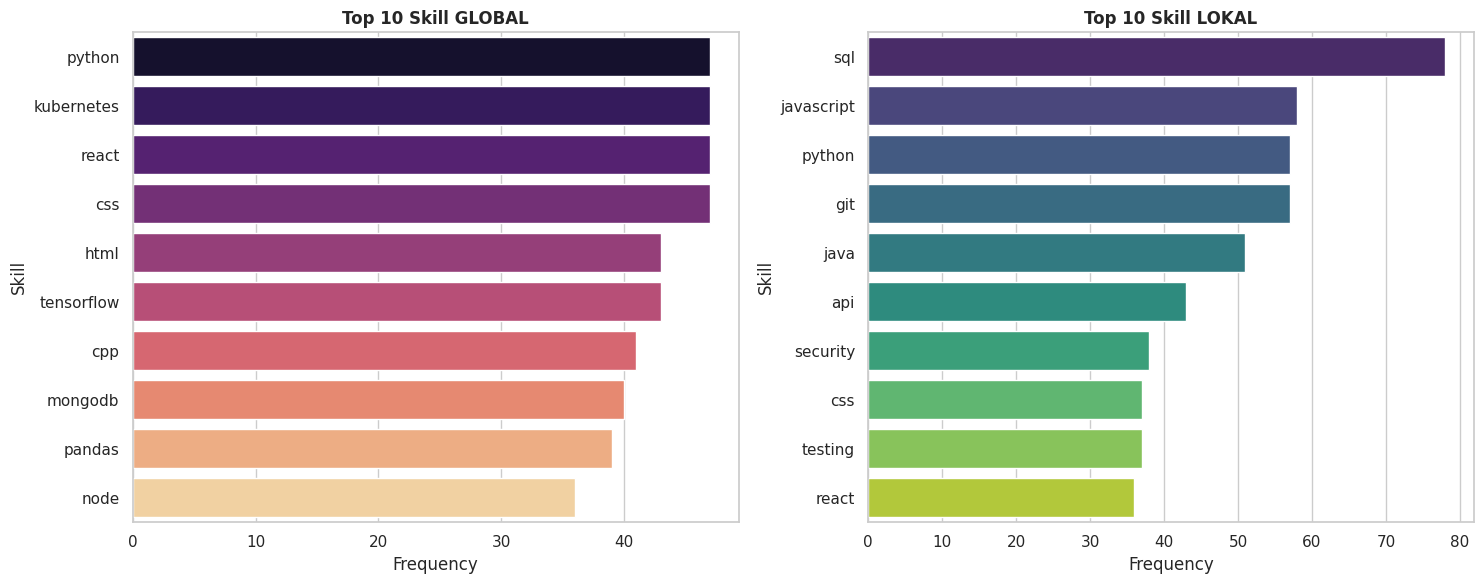

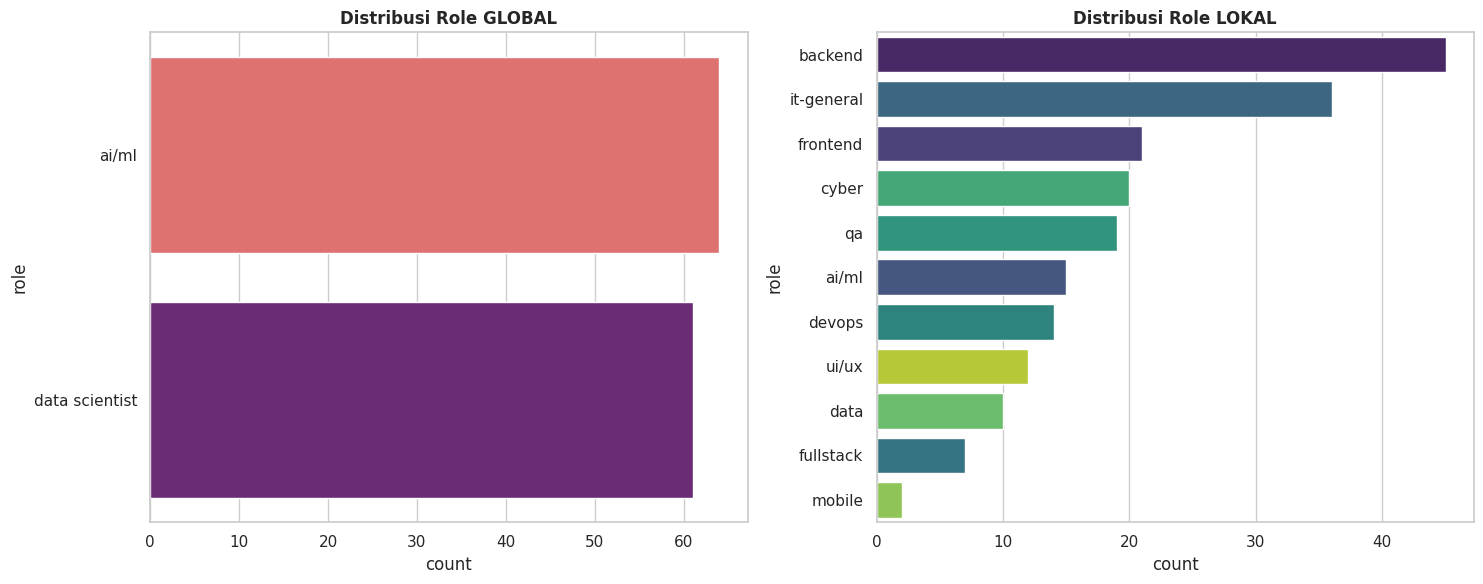

In [10]:
# Load dataset lokal milik Toroz
df_local = pd.read_csv('magangin_jobs_cleaned.csv')

# --- COMPLEXITY COMPARISON ---
avg_skill_local = df_local['skills_count'].mean()
print("=== Perbandingan Kompleksitas (Rata-rata Skill Count) ===")
print(f"Global : {avg_skill_global:.2f} skills per lowongan")
print(f"Lokal  : {avg_skill_local:.2f} skills per lowongan")

# --- SKILL COMPARISON ---
all_skills_local = []
for skills in df_local['skills'].dropna():
    all_skills_local.extend(str(skills).split(', '))

df_skills_local = pd.DataFrame(Counter(all_skills_local).items(), columns=['Skill', 'Frequency']).sort_values(by='Frequency', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Tambahan parameter hue='Skill' dan legend=False
sns.barplot(data=df_skills_global.head(10), x='Frequency', y='Skill', hue='Skill', palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Skill GLOBAL', fontweight='bold')

sns.barplot(data=df_skills_local.head(10), x='Frequency', y='Skill', hue='Skill', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Skill LOKAL', fontweight='bold')
plt.tight_layout()
plt.show()

# --- ROLE COMPARISON ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Tambahan parameter hue='role' dan legend=False
sns.countplot(data=df_global, y='role', order=df_global['role'].value_counts().index, hue='role', palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Role GLOBAL', fontweight='bold')

sns.countplot(data=df_local, y='role', order=df_local['role'].value_counts().index, hue='role', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Distribusi Role LOKAL', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Key Insights
Setelah melakukan *benchmarking* antara dataset Global dan Lokal, ditemukan 3 *insight* utama:
1. **Perbedaan Kebutuhan Skill:** Pasar global mencari kandidat dengan *skill* spesifik sesuai *niche* (Python untuk AI, Kotlin/Android Studio untuk Mobile). Sebaliknya, pasar lokal Indonesia sangat bergantung pada fundamental *Web Development*, di mana *skill* seperti SQL, JavaScript, Java, CSS, dan HTML menjadi raja.
2. **Realita "Palugada" di Pasar Lokal:** Tingkat kompleksitas (jumlah *skill* yang diminta) di Indonesia justru lebih tinggi (**6.37 skill/lowongan**) dibandingkan tingkat global (**4.47 skill/lowongan**). Perusahaan lokal cenderung mencari kandidat *all-rounder* yang bisa menangani banyak *tools* sekaligus.
3. **Perbedaan Distribusi Role:** Industri global bergerak fokus ke arah AI/ML dan Mobile, sementara industri lokal di Indonesia masih memprioritaskan ketahanan ekosistem digital dasar dengan tingginya permintaan untuk posisi **Backend** (sangat mendominasi) dan **IT-General**.

## 10. Conclusion
**Ringkasan:**
Hasil *benchmarking* menunjukkan perbedaan karakter yang kontras. Pasar global mencari "Spesialis" (Role AI/ML atau Mobile dengan rata-rata 4-5 *skill* yang mendalam). Di sisi lain, pasar Indonesia mencari "Generalist" atau *all-rounder* (Role Backend dengan tuntutan 6-7 *skill* lintas ekosistem seperti SQL, JS, HTML, CSS).

**Relevansi terhadap project Magang-in:**
*Insight* ini membuktikan bahwa sistem rekomendasi **Magang-in** harus adaptif. Platform harus mampu mencocokkan mahasiswa dengan realita kebutuhan lokal yang meminta banyak *skill web/backend*. Namun, platform juga harus menyisipkan rekomendasi *upskilling* (misalnya menyarankan belajar Python) agar mahasiswa mulai mencicil portofolio untuk tren masa depan yang mengarah ke AI/ML sesuai standar global.